# Задание 2: Прогноз суточного дебита (ML)
**Цель:** Обучить модели Linear Regression и Random Forest для предсказания суточной добычи нефти на основе телеметрии оборудования.

## 1. Импорты

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from minio import Minio
import pyarrow.parquet as pq
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

MINIO_ENDPOINT = 'minio:9000'
client = Minio(MINIO_ENDPOINT, access_key='minioadmin',
               secret_key='minioadmin123', secure=False)
BUCKET = 'oil-pipeline'

def read_parquet(prefix):
    objs = list(client.list_objects(BUCKET, prefix=prefix, recursive=True))
    dfs = []
    for obj in objs:
        if obj.object_name.endswith('.parquet'):
            resp = client.get_object(BUCKET, obj.object_name)
            dfs.append(pq.read_table(io.BytesIO(resp.read())).to_pandas())
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print('Импорты OK')

Импорты OK


## 2. Загрузка данных

In [2]:
df_telem   = read_parquet('raw/well_telemetry/')
df_targets = read_parquet('raw/well_targets/')
df_prod    = read_parquet('raw/production/')

df_telem['timestamp'] = pd.to_datetime(df_telem['timestamp'])
df_telem['date']      = df_telem['timestamp'].dt.date
df_targets['date']    = pd.to_datetime(df_targets['date']).dt.date
df_prod['date']       = pd.to_datetime(df_prod['date']).dt.date

print(f'Телеметрия: {len(df_telem)} записей')
print(f'Цели (well_targets): {len(df_targets)} записей')
df_telem.head(3)

Телеметрия: 48 записей
Цели (well_targets): 90 записей


,record_id,well_id,timestamp,pump_speed_rpm,pump_current,pressure_in,pressure_out,temperature,vibration,oil_flow_rate,date
0,1,1,2025-10-01 00:00:00,1470.0,58.2,95.3,122.4,88.1,1.4,8.8,2025-10-01
1,2,1,2025-10-01 01:00:00,1468.0,58.5,95.1,122.1,88.2,1.5,8.9,2025-10-01
2,3,1,2025-10-01 02:00:00,1472.0,58.0,94.9,121.8,88.3,1.6,8.7,2025-10-01


## 3. Подготовка датасета — агрегация телеметрии по дням

In [3]:
# Агрегируем телеметрию → суточные показатели
telem_daily = df_telem.groupby(['well_id', 'date']).agg(
    avg_pressure_in  = ('pressure_in',     'mean'),
    avg_pressure_out = ('pressure_out',    'mean'),
    avg_temperature  = ('temperature',     'mean'),
    avg_vibration    = ('vibration',       'mean'),
    avg_rpm          = ('pump_speed_rpm',  'mean'),
    avg_current      = ('pump_current',    'mean'),
    max_rpm          = ('pump_speed_rpm',  'max'),
    min_pressure_in  = ('pressure_in',     'min'),
    hours_active     = ('pump_speed_rpm',  'count'),
).reset_index()

# Присоединяем данные из production для pump_hours
prod_features = df_prod.groupby(['well_id', 'date']).agg(
    energy_kwh    = ('energy_kwh',     'sum'),
    downtime_hours= ('downtime_hours', 'sum'),
).reset_index()
prod_features['pump_hours'] = 24 - prod_features['downtime_hours'].clip(upper=24)

# Объединяем с целевой переменной
dataset = telem_daily.merge(df_targets, on=['well_id', 'date'], how='inner')
dataset = dataset.merge(prod_features[['well_id', 'date', 'pump_hours', 'energy_kwh']],
                        on=['well_id', 'date'], how='left')

# Фичи и целевая переменная
FEATURES = ['avg_pressure_in', 'avg_pressure_out', 'avg_temperature',
            'avg_vibration', 'avg_rpm', 'avg_current', 'pump_hours', 'energy_kwh']
TARGET   = 'daily_oil_ton'

dataset = dataset.dropna(subset=FEATURES + [TARGET])
print(f'Датасет: {len(dataset)} строк, {len(FEATURES)} фичей')
display(dataset[FEATURES + [TARGET]].describe())

Датасет: 2 строк, 8 фичей


,avg_pressure_in,avg_pressure_out,avg_temperature,avg_vibration,avg_rpm,avg_current,pump_hours,energy_kwh,daily_oil_ton
count,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000
mean,93.179167,118.875000,86.318750,1.452083,1451.604167,56.522917,23.350000,7125.000000,199.15000
std,2.675221,4.749401,2.784233,0.014731,29.610096,2.648704,0.212132,459.619408,18.73833
min,91.287500,115.516667,84.350000,1.441667,1430.666667,54.650000,23.200000,6800.000000,185.90000
25%,92.233333,117.195833,85.334375,1.446875,1441.135417,55.586458,23.275000,6962.500000,192.52500
50%,93.179167,118.875000,86.318750,1.452083,1451.604167,56.522917,23.350000,7125.000000,199.15000
75%,94.125000,120.554167,87.303125,1.457292,1462.072917,57.459375,23.425000,7287.500000,205.77500
max,95.070833,122.233333,88.287500,1.462500,1472.541667,58.395833,23.500000,7450.000000,212.40000


## 4. Разбивка на train/test и масштабирование

In [4]:
X = dataset[FEATURES].values
y = dataset[TARGET].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, dataset.index, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 1, Test: 1


## 5. Обучение моделей

In [5]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)       # RF не требует масштабирования
y_pred_rf = rf.predict(X_test)


def metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{name:25s}  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}')
    return mae, rmse, r2

print('Метрики качества моделей:')
print('-' * 60)
mae_lr, rmse_lr, r2_lr = metrics(y_test, y_pred_lr, 'Linear Regression')
mae_rf, rmse_rf, r2_rf = metrics(y_test, y_pred_rf, 'Random Forest')

Метрики качества моделей:
------------------------------------------------------------
Linear Regression          MAE=26.500  RMSE=26.500  R²=nan
Random Forest              MAE=26.500  RMSE=26.500  R²=nan


## 6. Важность признаков (Random Forest)

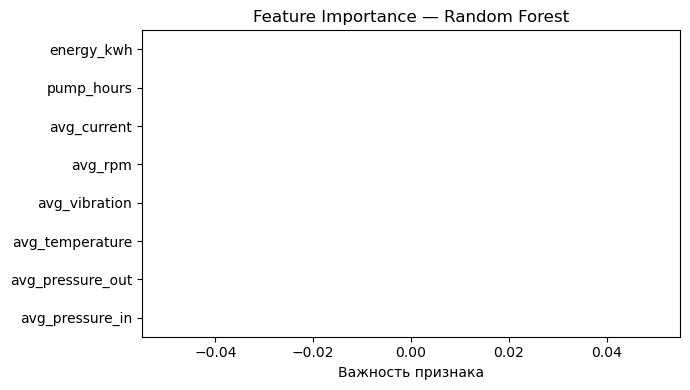

In [6]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Важность признака')
ax.set_title('Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('chart_04_feature_importance.png', dpi=150)
plt.show()

## 7. Визуализация: Actual vs Predicted

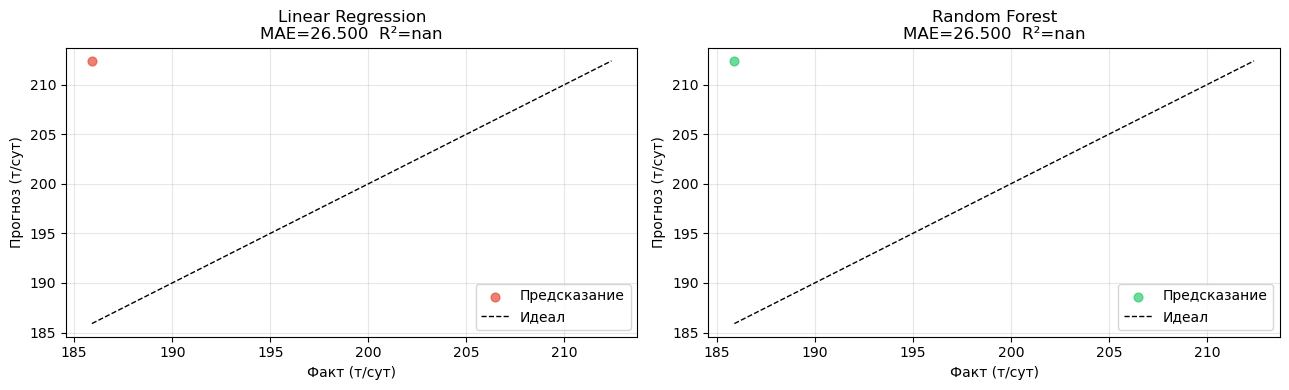

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, y_pred, name, clr in [
    (axes[0], y_pred_lr, 'Linear Regression', '#e74c3c'),
    (axes[1], y_pred_rf, 'Random Forest',     '#2ecc71'),
]:
    ax.scatter(y_test, y_pred, alpha=0.7, color=clr, s=40, label='Предсказание')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1, label='Идеал')
    ax.set_xlabel('Факт (т/сут)')
    ax.set_ylabel('Прогноз (т/сут)')
    ax.set_title(f'{name}\nMAE={mean_absolute_error(y_test,y_pred):.3f}  R²={r2_score(y_test,y_pred):.4f}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart_05_actual_vs_predicted.png', dpi=150)
plt.show()

## 8. Ошибка модели по времени

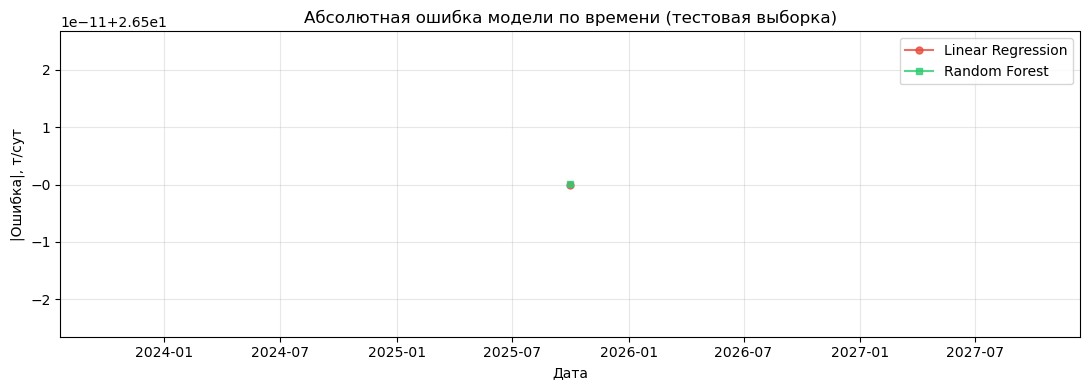

In [8]:
test_df = dataset.loc[idx_test].copy()
test_df['pred_lr'] = y_pred_lr
test_df['pred_rf'] = y_pred_rf
test_df['error_lr'] = abs(test_df['daily_oil_ton'] - test_df['pred_lr'])
test_df['error_rf'] = abs(test_df['daily_oil_ton'] - test_df['pred_rf'])
test_df['date'] = pd.to_datetime(test_df['date'])
test_df = test_df.sort_values('date')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test_df['date'], test_df['error_lr'], marker='o', ms=5,
        label='Linear Regression', color='#e74c3c', alpha=0.8)
ax.plot(test_df['date'], test_df['error_rf'], marker='s', ms=5,
        label='Random Forest', color='#2ecc71', alpha=0.8)
ax.set_xlabel('Дата')
ax.set_ylabel('|Ошибка|, т/сут')
ax.set_title('Абсолютная ошибка модели по времени (тестовая выборка)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart_06_error_over_time.png', dpi=150)
plt.show()

## 9. Сохранение прогнозов обратно в MinIO

In [9]:
import pyarrow as pa
import pyarrow.parquet as pq

all_pred = dataset.copy()
all_pred['pred_rf'] = rf.predict(X)
all_pred['pred_lr'] = lr.predict(scaler.transform(X))

save_cols = ['well_id', 'date', 'daily_oil_ton', 'pred_rf', 'pred_lr']
pred_table = pa.Table.from_pandas(all_pred[save_cols], preserve_index=False)
buf = io.BytesIO()
pq.write_table(pred_table, buf)
buf.seek(0)
data = buf.read()

client.put_object(
    BUCKET, 'mart/ml_predictions/predictions.parquet',
    data=io.BytesIO(data), length=len(data),
    content_type='application/octet-stream'
)
print('Прогнозы сохранены → s3://oil-pipeline/mart/ml_predictions/predictions.parquet')

Прогнозы сохранены → s3://oil-pipeline/mart/ml_predictions/predictions.parquet


## 10. Итоги

In [10]:
print('=' * 55)
print('ИТОГИ — Прогноз дебита')
print('=' * 55)
print(f"Linear Regression: MAE={mae_lr:.3f} т/сут, RMSE={rmse_lr:.3f}, R²={r2_lr:.4f}")
print(f"Random Forest:     MAE={mae_rf:.3f} т/сут, RMSE={rmse_rf:.3f}, R²={r2_rf:.4f}")
print()
best_model = 'Random Forest' if r2_rf > r2_lr else 'Linear Regression'
print(f'Лучшая модель: {best_model}')
print()
top_feature = importances.idxmax()
print(f'Самый важный признак (RF): {top_feature}')

ИТОГИ — Прогноз дебита
Linear Regression: MAE=26.500 т/сут, RMSE=26.500, R²=nan
Random Forest:     MAE=26.500 т/сут, RMSE=26.500, R²=nan

Лучшая модель: Linear Regression

Самый важный признак (RF): avg_pressure_in
